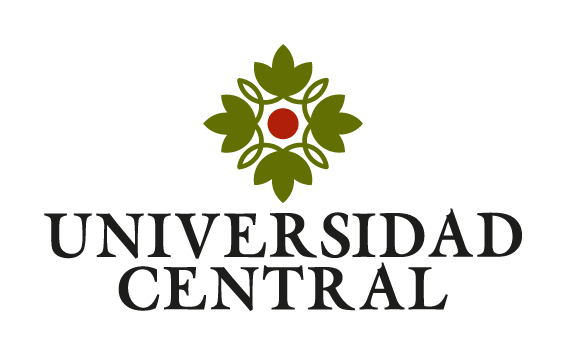

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 16 de 2026

Taller: Trabajo Final

# Etapa 1. Captura y Preparación de Datos

**Subetapa 1A — Captura de archivos en formato PDF** para posterior y Preparación de Datos del prototipo RAG-jurimétrico.
<br>
<br>
Este Notebook realiza la extracción de actos administrativos sancionadores - Autoridad Nacional de Licencias Ambientales.
<br>
<br>
Fuente oficial: https://gaceta.anla.gov.co:8443/Consultar-gaceta.
<br>
<br>
Este script realiza solicitudes controladas al endpoint público
para obtener documentos oficiales (PDF) de carácter público,
de acuerdo con las políticas de acceso establecidas por la entidad.
<br>
<br>
Uso educativo y de investigación (no comercial).
Autor: Katterine Cardozo - Oswaldo Salgado Gómez


# HOJA DE RUTA A SEGUIR

0.  Montar Google Drive
1.  Instalar librerías
2.  Configuración General
3.  Utilidades
4.  Request Robusto
5.  Parse de Resultados WEB
6.  Diccionarios y Reglas
7.  Scoring y Filtrado Temprano
8.  Recolección de Candidatos
9.  Descarga Robusta
10. Lecturas PDF
11. Expresiones Regulares Jurídicas
12. Extracción Jurídica
13. Segmentación del Texto
14. Clasificación Procedimental
15. Procesamiento Individual
16. Reporte de Calidad
17. Main


#0\. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#1\. Instalar Librerias

In [ ]:
import re
import csv
import json
import time
import random
import shutil
import hashlib
import unicodedata
from datetime import datetime
from pathlib import Path
from collections import defaultdict

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

from bs4 import BeautifulSoup, FeatureNotFound
from tqdm import tqdm

import fitz  # PyMuPDF

#2\. Configuración General





In [ ]:
# -*- coding: utf-8 -*-
"""
ANLA GACETA SCRAPER - VERSION 3
Corpus jurídico estructurado para analítica legal

Objetivo:
- Construir un corpus jurídico estructurado de actos administrativos sancionatorios ambientales ANLA
- Extraer metadatos documentales, variables jurídicas y texto segmentado
- Delimitar corpus al sector hidrocarburos
- Generar salidas para LIR, PLN y jurimetría exploratoria

Salidas:
- hallazgos_busqueda.csv
- candidatos.csv
- documentos_master.csv
- variables_juridicas.csv
- textos_segmentados.csv
- quality_report.csv
- json_docs/{pdf_id}.json
- pdfs organizados por expediente/categoría

Notas:
- OCR está desactivado por defecto
- Este pipeline NO predice decisiones; solo estructura y describe información pública
"""

BASE_DIR_ANLA = r"C:\Users\katte\OneDrive\Documentos\MAESTRIA_ANALITICA_DATOS\07_TRABAJOS\Profundizacion"
BASE_DIR = Path(BASE_DIR_ANLA)

PDF_DIR = BASE_DIR / "ANLA_pdf"
TMP_DIR = PDF_DIR / "_tmp"
OK_DIR = PDF_DIR / "_OK"
DESCARTADOS_DIR = PDF_DIR / "_DESCARTADOS"
NO_VALIDOS_DIR = PDF_DIR / "_NO_VALIDOS"

LOG_DIR = BASE_DIR / "logs"
CSV_DIR = BASE_DIR / "csv"
JSON_DIR = BASE_DIR / "json_docs"
TEXT_DIR = BASE_DIR / "txt_docs"

for p in [PDF_DIR, TMP_DIR, OK_DIR, DESCARTADOS_DIR, NO_VALIDOS_DIR, LOG_DIR, CSV_DIR, JSON_DIR, TEXT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Logs
LOG_DEBUG = LOG_DIR / "debug.txt"
LOG_ERRORES = LOG_DIR / "errores.txt"
LOG_DESCARGAS = LOG_DIR / "descargas_ok.txt"
PROCESSED_IDS_FILE = LOG_DIR / "processed_ids.txt"

# CSV
HALLAZGOS_CSV = CSV_DIR / "hallazgos_busqueda.csv"
CANDIDATOS_CSV = CSV_DIR / "candidatos.csv"
DOC_MASTER_CSV = CSV_DIR / "documentos_master.csv"
VARS_JURIDICAS_CSV = CSV_DIR / "variables_juridicas.csv"
TEXTOS_SEG_CSV = CSV_DIR / "textos_segmentados.csv"
QUALITY_REPORT_CSV = CSV_DIR / "quality_report.csv"

# Endpoints
GACETA_ENDPOINT = "https://gaceta.anla.gov.co:8443/Consultar-gaceta/consultar"
BASE_DESCARGA = "https://gaceta.anla.gov.co:8443/Consultar-gaceta/descargar"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
}

# Tiempos
TIMEOUT = (10, 35)
DELAY_BASE = 1.0
DELAY_JITTER = 0.8
SLEEP_EVERY_PAGES = 3

# Búsqueda
MAX_PAGINAS_POR_TERMINO = 80
STOP_SIN_NUEVOS = 6

# OCR
OCR_ENABLED = False
MIN_TEXT_LEN_BEFORE_OCR = 250

# Modo de corpus
# Opciones:
# - general_sancionatorio
# - hidrocarburos_ampliado
# - hidrocarburos_estricto
CORPUS_MODO = "general_sancionatorio"

# Forzar solo ESTA corrida como si fuera la primera vez
FORZAR_PRIMERA_EJECUCION = True

# Términos de búsqueda
TERMINOS_BUSQUEDA = [
    "ley 1333",
    "procedimiento sancionatorio ambiental",
    "indagación preliminar",
    "formulación de cargos",
    "práctica de pruebas",
    "resolución sancionatoria",
    "recurso de reposición",
    "recurso de apelación",
    "archivo expediente sancionatorio",
    "medida preventiva"
]


# 3\. Utilidades

In [ ]:
def now():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def log_line(path: Path, line: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(line + "\n")


def polite_sleep(base=DELAY_BASE, jitter=DELAY_JITTER):
    time.sleep(base + random.random() * jitter)


def normalizar(txt: str) -> str:
    if not txt:
        return ""
    txt = txt.lower().strip()
    txt = unicodedata.normalize("NFD", txt)
    txt = "".join(c for c in txt if unicodedata.category(c) != "Mn")
    txt = re.sub(r"\s+", " ", txt)
    return txt


def clean_text_for_storage(txt: str) -> str:
    txt = txt or ""
    txt = txt.replace("\x00", " ")
    txt = re.sub(r"[ \t]+", " ", txt)
    txt = re.sub(r"\n{3,}", "\n\n", txt)
    return txt.strip()


def first_non_empty(*values):
    for v in values:
        if v and str(v).strip():
            return str(v).strip()
    return ""


def make_soup(html: str):
    try:
        return BeautifulSoup(html, "lxml")
    except FeatureNotFound:
        return BeautifulSoup(html, "html.parser")
    except Exception:
        return BeautifulSoup(html, "html.parser")


def load_processed_ids() -> set:
    if not PROCESSED_IDS_FILE.exists():
        return set()
    with open(PROCESSED_IDS_FILE, "r", encoding="utf-8") as f:
        return {line.strip() for line in f if line.strip()}


def save_processed_id(pdf_id: str):
    with open(PROCESSED_IDS_FILE, "a", encoding="utf-8") as f:
        f.write(str(pdf_id).strip() + "\n")


def file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def append_row(csv_path: Path, row: list):
    with open(csv_path, "a", newline="", encoding="utf-8-sig") as f:
        w = csv.writer(f)
        w.writerow(row)


def dump_json(path: Path, data: dict):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def save_text_file(path: Path, text: str):
    with open(path, "w", encoding="utf-8") as f:
        f.write(text or "")


def unique_list(values):
    out = []
    seen = set()
    for v in values:
        if v not in seen:
            out.append(v)
            seen.add(v)
    return out


def safe_unlink(path: Path):
    try:
        if path.exists():
            path.unlink()
    except Exception as e:
        print(f"No se pudo borrar archivo {path}: {e}")


def safe_rmtree(path: Path):
    try:
        if path.exists():
            shutil.rmtree(path)
    except Exception as e:
        print(f"No se pudo borrar carpeta {path}: {e}")


def forzar_primera_ejecucion():
    """
    Limpia archivos de control y salidas analíticas
    para que esta corrida se comporte como la primera vez.
    No borra la estructura principal del proyecto ni los PDFs finales ya guardados.
    """
    print("\n=== FORZANDO PRIMERA EJECUCIÓN (solo esta vez) ===")

    archivos_a_borrar = [
        PROCESSED_IDS_FILE,
        HALLAZGOS_CSV,
        CANDIDATOS_CSV,
        DOC_MASTER_CSV,
        VARS_JURIDICAS_CSV,
        TEXTOS_SEG_CSV,
        QUALITY_REPORT_CSV,
        LOG_DEBUG,
        LOG_ERRORES,
        LOG_DESCARGAS,
    ]

    for archivo in archivos_a_borrar:
        try:
            if archivo.exists():
                archivo.unlink()
                print(f"Borrado: {archivo.name}")
        except Exception as e:
            print(f"No se pudo borrar {archivo}: {e}")

    # Reiniciar temporales
    try:
        if TMP_DIR.exists():
            shutil.rmtree(TMP_DIR)
        TMP_DIR.mkdir(parents=True, exist_ok=True)
        print("Carpeta temporal reiniciada.")
    except Exception as e:
        print(f"No se pudo reiniciar TMP_DIR: {e}")

    # Reiniciar salidas analíticas
    for carpeta in [JSON_DIR, TEXT_DIR]:
        try:
            if carpeta.exists():
                shutil.rmtree(carpeta)
            carpeta.mkdir(parents=True, exist_ok=True)
            print(f"Reiniciada carpeta: {carpeta.name}")
        except Exception as e:
            print(f"No se pudo reiniciar {carpeta}: {e}")

    print("=== FIN REINICIO TEMPORAL ===\n")


def init_csvs():
    if not HALLAZGOS_CSV.exists():
        with open(HALLAZGOS_CSV, "w", newline="", encoding="utf-8-sig") as f:
            w = csv.writer(f)
            w.writerow([
                "timestamp", "pdf_id", "termino_busqueda", "pagina",
                "score_tarjeta", "score_hidro", "score_sector_empresa"
            ])

    if not CANDIDATOS_CSV.exists():
        with open(CANDIDATOS_CSV, "w", newline="", encoding="utf-8-sig") as f:
            w = csv.writer(f)
            w.writerow([
                "timestamp", "pdf_id", "titulo", "proyecto", "descripcion",
                "texto_busqueda", "score_tarjeta_max", "score_hidro_max",
                "score_sector_empresa_max", "hallazgos", "terminos", "paginas"
            ])

    if not DOC_MASTER_CSV.exists():
        with open(DOC_MASTER_CSV, "w", newline="", encoding="utf-8-sig") as f:
            w = csv.writer(f)
            w.writerow([
                "timestamp", "pdf_id", "status_tecnico",
                "titulo_web", "descripcion_web", "proyecto_web",
                "final_path", "txt_path", "json_path",
                "file_size", "page_count", "sha256",
                "error_tipo", "content_quality",
                "score_tarjeta", "score_hidro", "score_sector_empresa"
            ])

    if not VARS_JURIDICAS_CSV.exists():
        with open(VARS_JURIDICAS_CSV, "w", newline="", encoding="utf-8-sig") as f:
            w = csv.writer(f)
            w.writerow([
                "timestamp", "pdf_id",
                "fecha_acto", "anio_acto", "mes_acto",
                "numero_acto", "tipo_acto",
                "categoria_num", "categoria_nombre", "fase_procedimental",
                "expediente_lam", "expediente_san", "expediente_general",
                "proceso_sancionatorio", "concepto_tecnico",
                "empresa_investigada", "proyecto_objeto", "ubicacion_geografica",
                "sector_clasificado", "es_hidrocarburos",
                "normas_citadas", "numero_normas_citadas",
                "decision_final", "tipo_sancion", "valor_multa",
                "decision_recurso", "tipo_infraccion_aprox",
                "score_sancionatorio_pos", "score_sancionatorio_neg"
            ])

    if not TEXTOS_SEG_CSV.exists():
        with open(TEXTOS_SEG_CSV, "w", newline="", encoding="utf-8-sig") as f:
            w = csv.writer(f)
            w.writerow([
                "timestamp", "pdf_id",
                "texto_len", "hechos_len", "cons_juridicas_len",
                "cons_tecnicas_len", "resolutiva_len",
                "texto_resumen_500"
            ])

    if not QUALITY_REPORT_CSV.exists():
        with open(QUALITY_REPORT_CSV, "w", newline="", encoding="utf-8-sig") as f:
            w = csv.writer(f)
            w.writerow([
                "timestamp", "metrica", "valor"
            ])



#4\. Request Robusto

In [ ]:
def build_session() -> requests.Session:
    s = requests.Session()
    retry = Retry(
        total=5,
        read=5,
        connect=5,
        backoff_factor=1.2,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"]
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=20, pool_maxsize=20)
    s.mount("https://", adapter)
    s.mount("http://", adapter)
    return s


def get_with_timeout(session, url, params=None, stream=False):
    return session.get(url, params=params, headers=HEADERS, timeout=TIMEOUT, stream=stream)


#5\. Parse de Resultados WEB

In [ ]:

def obtener_soup_gaceta(session, pagina=1, palabra=""):
    params = {
        "pagina": pagina,
        "buscar_numero_documento": "",
        "buscar_desde_fecha_documento": "",
        "buscar_hasta_fecha_documento": "",
        "buscar_tipo_documento": "",
        "buscar_expediente": "",
        "buscar_fecha": "",
        "buscar_ubicacion": "",
        "buscar_documento": palabra
    }
    r = get_with_timeout(session, GACETA_ENDPOINT, params=params, stream=False)
    r.raise_for_status()
    return make_soup(r.text)


def extraer_tarjetas_desde_soup(soup):
    resultados = []
    cards = soup.find_all("div", class_="member")

    for card in cards:
        heading = card.find("div", class_="item-box-blog-heading")
        h5 = heading.find("h5") if heading else None
        titulo = h5.get_text(strip=True) if h5 else "(sin título)"

        proyecto = ""
        descripcion = ""

        for p in card.find_all("p"):
            texto_p = p.get_text(" ", strip=True)
            if "Nombre de proyecto" in texto_p:
                proyecto = texto_p.replace("Nombre de proyecto:", "").strip()
            elif "Descripción" in texto_p:
                descripcion = texto_p.replace("Descripción:", "").strip()

        pdf_id = None
        for a in card.find_all("a", onclick=True):
            onclick = a.get("onclick", "")
            m = re.search(r"descargar\((\d+)\)", onclick)
            if m:
                pdf_id = m.group(1)
                break

        if not pdf_id:
            continue

        texto_busqueda = " ".join(x for x in [titulo, proyecto, descripcion] if x)

        resultados.append({
            "pdf_id": str(pdf_id),
            "titulo": titulo,
            "proyecto": proyecto,
            "descripcion": descripcion,
            "texto_busqueda": texto_busqueda
        })

    return resultados

#6\. Diccionarios y Reglas

In [ ]:
RE_SAN = re.compile(r"\bSAN\d{3,5}(?:-\d{2})?-\d{4}\b", re.IGNORECASE)

KW_TARJ_POS = [
    "sancionatorio", "ley 1333", "formulacion de cargos", "indagacion preliminar",
    "resolucion sancionatoria", "multa", "medida preventiva", "archivo",
    "recurso de reposicion", "recurso de apelacion", "investigacion sancionatoria"
]

KW_TARJ_NEG = [
    "licencia ambiental", "otorga licencia", "modifica la licencia",
    "seguimiento ambiental", "plan de manejo", "pma", "ica",
    "inversion del 1%", "inversion forzosa", "compensacion forestal",
    "aprovechamiento forestal", "concesion", "permiso"
]

KW_HIDRO_POS = [
    "hidrocarb", "petroleo", "petróleo", "crudo", "oleoduct", "gasoduct",
    "pozo", "perforacion", "perforación", "exploracion", "exploración",
    "produccion", "producción", "bloque petrolero", "campo petrolero",
    "estacion de flujo", "estación de flujo", "linea de flujo", "línea de flujo",
    "ecopetrol", "parex", "frontera energy", "gran tierra", "hocol", "canacol",
    "perenco", "ocensa", "cenit", "oleoducto", "gas", "upstream", "downstream"
]

KW_HIDRO_NEG = [
    "gas natural domiciliario",
    "bloque de concreto",
    "operacion administrativa"
]

EMPRESAS_HIDRO = [
    "ecopetrol", "parex", "frontera energy", "gran tierra", "hocol", "canacol",
    "perenco", "ocensa", "cenit", "equion", "geo park", "geopark", "repsol",
    "amerisur", "sierracol", "sierra col", "maurel", "promigas"
]

TIPO_INFRACCION_KW = {
    "vertimientos": ["vertimiento", "vertimientos", "agua residual", "aguas residuales"],
    "emisiones_atmosfericas": ["emision", "emisiones", "atmosfer", "calidad del aire"],
    "aprovechamiento_forestal": ["aprovechamiento forestal", "tala", "aprovechamiento"],
    "residuos_peligrosos": ["respel", "residuo peligroso", "residuos peligrosos"],
    "afectacion_hidrico": ["captacion", "ocupacion de cauce", "concesion de aguas", "cauce"],
    "fauna_flora": ["fauna", "flora", "biodiversidad", "especie"],
    "incumplimiento_licencia": ["licencia ambiental", "incumplimiento", "obligacion", "obligación"],
    "contingencia_derrame": ["derrame", "fuga", "contingencia", "hidrocarburo derramado"]
}


#7\. Scoring y Filtrado Temprano

In [ ]:

def score_keywords(texto, keywords, weight=1):
    t = normalizar(texto)
    score = 0
    for kw in keywords:
        if normalizar(kw) in t:
            score += weight
    return score


def score_tarjeta(texto):
    score = score_keywords(texto, KW_TARJ_POS, weight=2)
    score -= score_keywords(texto, KW_TARJ_NEG, weight=2)
    if RE_SAN.search(texto or ""):
        score += 3
    return score


def score_hidrocarburos(texto):
    score = score_keywords(texto, KW_HIDRO_POS, weight=2)
    score -= score_keywords(texto, KW_HIDRO_NEG, weight=2)
    return score


def score_sector_empresa(texto):
    return score_keywords(texto, EMPRESAS_HIDRO, weight=3)


def pasa_filtro_corpus(score_t, score_h, score_e):
    if CORPUS_MODO == "general_sancionatorio":
        return score_t >= 2
    if CORPUS_MODO == "hidrocarburos_ampliado":
        return (score_t >= 2) and ((score_h >= 2) or (score_e >= 3))
    if CORPUS_MODO == "hidrocarburos_estricto":
        return (score_t >= 3) and ((score_h >= 4) or (score_e >= 3))
    return score_t >= 2


def agregar_candidato(candidatos, tarjeta, termino, pagina, score_t, score_h, score_e):
    pid = tarjeta["pdf_id"]

    if pid not in candidatos:
        candidatos[pid] = {
            "pdf_id": pid,
            "titulo": tarjeta["titulo"],
            "proyecto": tarjeta["proyecto"],
            "descripcion": tarjeta["descripcion"],
            "texto_busqueda": tarjeta["texto_busqueda"],
            "terminos": {termino},
            "paginas": {pagina},
            "score_tarjeta_max": score_t,
            "score_hidro_max": score_h,
            "score_sector_empresa_max": score_e,
            "hallazgos": 1,
            "timestamp": now()
        }
    else:
        candidatos[pid]["terminos"].add(termino)
        candidatos[pid]["paginas"].add(pagina)
        candidatos[pid]["hallazgos"] += 1
        candidatos[pid]["score_tarjeta_max"] = max(candidatos[pid]["score_tarjeta_max"], score_t)
        candidatos[pid]["score_hidro_max"] = max(candidatos[pid]["score_hidro_max"], score_h)
        candidatos[pid]["score_sector_empresa_max"] = max(candidatos[pid]["score_sector_empresa_max"], score_e)


#8\. Recolección de Candidatos

In [ ]:

def recolectar_candidatos(session, processed_ids):
    candidatos = {}

    for termino in TERMINOS_BUSQUEDA:
        print(f"\n=== BUSCANDO: {termino} ===")
        sin_nuevos = 0

        for pagina in range(1, MAX_PAGINAS_POR_TERMINO + 1):
            try:
                soup = obtener_soup_gaceta(session, pagina=pagina, palabra=termino)
                tarjetas = extraer_tarjetas_desde_soup(soup)

                if not tarjetas:
                    print("Sin más tarjetas. Fin del término.")
                    break

                nuevos_pagina = 0

                for t in tarjetas:
                    pid = t["pdf_id"]
                    if pid in processed_ids:
                        continue

                    score_t = score_tarjeta(t["texto_busqueda"])
                    score_h = score_hidrocarburos(t["texto_busqueda"])
                    score_e = score_sector_empresa(t["texto_busqueda"])

                    if not pasa_filtro_corpus(score_t, score_h, score_e):
                        continue

                    agregar_candidato(candidatos, t, termino, pagina, score_t, score_h, score_e)
                    nuevos_pagina += 1

                    append_row(HALLAZGOS_CSV, [
                        now(), pid, termino, pagina, score_t, score_h, score_e
                    ])

                print(f"Página {pagina} | nuevos={nuevos_pagina} | total={len(candidatos)}")

                if nuevos_pagina == 0:
                    sin_nuevos += 1
                else:
                    sin_nuevos = 0

                if sin_nuevos >= STOP_SIN_NUEVOS:
                    print(f"{STOP_SIN_NUEVOS} páginas seguidas sin nuevos. Fin del término.")
                    break

                if pagina % SLEEP_EVERY_PAGES == 0:
                    polite_sleep()

            except Exception as e:
                msg = f"[{now()}] ERROR búsqueda termino='{termino}' pagina={pagina} -> {e}"
                print(msg)
                log_line(LOG_ERRORES, msg)
                polite_sleep()
                continue

    return candidatos


def exportar_candidatos(candidatos):
    for c in candidatos.values():
        append_row(CANDIDATOS_CSV, [
            c["timestamp"],
            c["pdf_id"],
            c["titulo"],
            c["proyecto"],
            c["descripcion"],
            c["texto_busqueda"],
            c["score_tarjeta_max"],
            c["score_hidro_max"],
            c["score_sector_empresa_max"],
            c["hallazgos"],
            " | ".join(sorted(c["terminos"])),
            " | ".join(map(str, sorted(c["paginas"])))
        ])


def priorizar_candidatos(candidatos):
    return sorted(
        candidatos.values(),
        key=lambda x: (
            x["score_tarjeta_max"],
            x["score_hidro_max"],
            x["score_sector_empresa_max"],
            x["hallazgos"]
        ),
        reverse=True
    )


#9\. Descarga Robusta

In [ ]:

def descargar_pdf(session, pdf_id: str, destino: Path):
    if destino.exists() and destino.stat().st_size > 10000:
        return "EXISTE"

    url_real = f"{BASE_DESCARGA}?q={pdf_id}"

    with get_with_timeout(session, url_real, stream=True) as r:
        status = r.status_code
        if status != 200:
            raise Exception(f"HTTP_{status}")

        content_type = (r.headers.get("Content-Type", "") or "").lower()

        first = b""
        for chunk in r.iter_content(chunk_size=512):
            if chunk:
                first = chunk
                break

        if not first:
            raise Exception("EMPTY_RESPONSE")

        first_low = first.lower()
        if b"<html" in first_low or b"<!doctype" in first_low:
            snippet = first[:250].decode("utf-8", errors="ignore").replace("\n", " ")
            log_line(LOG_DEBUG, f"[{now()}] NO_PDF_HTML pdf_id={pdf_id} content_type={content_type} snippet={snippet}")
            raise Exception("NO_PDF_HTML")

        sin_bom = first.lstrip(b"\xef\xbb\xbf")
        if ("pdf" not in content_type) and (not sin_bom.startswith(b"%PDF")):
            log_line(LOG_DEBUG, f"[{now()}] NO_PDF_BINARY pdf_id={pdf_id} content_type={content_type} head={first[:30]!r}")
            raise Exception("NO_PDF_BINARY")

        destino.parent.mkdir(parents=True, exist_ok=True)
        with open(destino, "wb") as f:
            f.write(first)
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)

    if destino.stat().st_size < 5000:
        raise Exception("FILE_TOO_SMALL")

    return "DESCARGADO"


#10\. Lectura PDF

In [ ]:

def leer_pdf_texto_completo(pdf_path: Path):
    try:
        with fitz.open(str(pdf_path)) as doc:
            page_count = doc.page_count
            parts = []
            for i in range(page_count):
                try:
                    parts.append(doc.load_page(i).get_text("text"))
                except Exception:
                    parts.append("")
            txt = "\n".join(parts)

        txt = clean_text_for_storage(txt)

        if OCR_ENABLED and len(txt.strip()) < MIN_TEXT_LEN_BEFORE_OCR:
            pass

        return txt, page_count, pdf_path.stat().st_size

    except Exception as e:
        log_line(LOG_DEBUG, f"[{now()}] PDF_READ_FAIL {pdf_path.name} -> {e}")
        raise Exception("PDF_CORRUPTO_O_ILEGIBLE")


def evaluar_calidad_texto(txt: str):
    txt = txt or ""
    n = len(txt)
    if n == 0:
        return "VACIO"
    if n < 800:
        return "MUY_BAJO"
    if n < 3000:
        return "BAJO"
    if n < 10000:
        return "MEDIO"
    return "ALTO"


#11\. Expresiones Regulares Jurídicas

In [ ]:

RE_LAM_1 = re.compile(r"Expediente\s*(?:No\.?)?\s*[:\-]?\s*(LAM[0-9A-Z\-]{3,})", re.IGNORECASE)
RE_LAM_2 = re.compile(r"\bLAM[0-9]{3,}[0-9A-Z\-]*\b", re.IGNORECASE)

RE_EXP = [
    re.compile(r"Expediente\s*No\.?\s*[:\-]?\s*([A-Z0-9\-]{4,})", re.IGNORECASE),
    re.compile(r"Arch(?:i|í)vese\s*en\s*[:\-]?\s*([A-Z0-9\-]{4,})", re.IGNORECASE),
]
RE_PRO = [re.compile(r"Proceso\s*No\.?\s*[:\-]?\s*([0-9]{4,})", re.IGNORECASE)]
RE_CON = [re.compile(r"Concepto\s*T[eé]cnico\s*(?:No\.?|N°|Nº)?\s*[:\-]?\s*([0-9\-]{3,})", re.IGNORECASE)]

RE_FECHA = [
    re.compile(r"Bogot[aá][^0-9]{0,50}(\d{1,2}\s+de\s+[a-zA-Záéíóúñ]+\s+de\s+\d{4})", re.IGNORECASE),
    re.compile(r"(\d{1,2}[\/\-]\d{1,2}[\/\-]\d{4})"),
]

RE_NUMERO_ACTO = [
    re.compile(r"(Resoluci[oó]n|Auto)\s+(?:No\.?|N°|Nº)?\s*([0-9\-]{2,})", re.IGNORECASE),
]

RE_NORMAS = [
    re.compile(r"Ley\s+\d+\s+de\s+\d{4}", re.IGNORECASE),
    re.compile(r"Decreto\s+\d+\s+de\s+\d{4}", re.IGNORECASE),
    re.compile(r"Resoluci[oó]n\s+\d+\s+de\s+\d{4}", re.IGNORECASE),
    re.compile(r"art[ií]culo\s+\d+[A-Za-z\-]*", re.IGNORECASE),
    re.compile(r"art\.\s*\d+[A-Za-z\-]*", re.IGNORECASE),
]

RE_EMPRESA = [
    re.compile(r"contra\s+(?:la\s+empresa\s+|la\s+sociedad\s+|la\s+compa[nñ][ií]a\s+)?([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÑ0-9\.\-&\s]{4,80})", re.IGNORECASE),
    re.compile(r"titular\s+del\s+proyecto\s+(?:es\s+|corresponde\s+a\s+)?([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÑ0-9\.\-&\s]{4,80})", re.IGNORECASE),
]

RE_UBICACION = [
    re.compile(r"ubicad[oa]\s+en\s+([A-ZÁÉÍÓÚÑa-záéíóúñ,\-\s]{5,120})", re.IGNORECASE),
    re.compile(r"municipio\s+de\s+([A-ZÁÉÍÓÚÑa-záéíóúñ,\-\s]{3,120})", re.IGNORECASE),
]

RE_MULTA = [
    re.compile(r"\$\s?([\d\.\,]+)"),
    re.compile(r"multa\s+de\s+([\d\.\,]+)\s*(?:pesos|smmlv|smlmv)", re.IGNORECASE),
]

RE_REPO_SANC_CERCA = re.compile(
    r"recurso\s+de\s+reposici[oó]n[\s\S]{0,800}?(procedimiento\s+sancionatorio|sancionatorio\s+ambiental|ley\s+1333|\bSAN\d{3,5})",
    re.IGNORECASE
)
RE_APEL_SANC_CERCA = re.compile(
    r"recurso\s+de\s+apelaci[oó]n[\s\S]{0,800}?(procedimiento\s+sancionatorio|sancionatorio\s+ambiental|ley\s+1333|\bSAN\d{3,5})",
    re.IGNORECASE
)
RE_NEG_LIC_DURO = re.compile(
    r"(por\s+la\s+cual\s+se\s+otorga\s+licencia|por\s+la\s+cual\s+se\s+modifica\s+la\s+licencia|licencia\s+ambiental)",
    re.IGNORECASE
)

KW_POS_SANC = [
    "ley 1333",
    "procedimiento sancionatorio",
    "procedimiento sancionatorio ambiental",
    "proceso sancionatorio",
    "sancionatorio ambiental",
    "indagacion preliminar", "indagación preliminar",
    "inicio de un procedimiento sancionatorio",
    "apertura de investigacion", "apertura de investigación",
    "investigacion sancionatoria", "investigación sancionatoria",
    "formulacion de cargos", "formulación de cargos", "pliego de cargos",
    "decreta pruebas", "niega pruebas", "practica de pruebas", "práctica de pruebas",
    "traslado para alegatos",
    "resolucion sancionatoria", "resolución sancionatoria",
    "impone multa", "multa",
    "impone sancion", "impone sanción",
    "declara responsable", "responsabilidad sancionatoria",
    "medida preventiva", "medidas preventivas",
    "actuacion sancionatoria", "actuación sancionatoria",
    "archivo del expediente", "archivese", "archívese"
]

KW_NEG_NO_SANC = [
    "licencia ambiental",
    "otorga licencia",
    "modifica la licencia",
    "pma",
    "plan de manejo ambiental",
    "eia",
    "estudio de impacto ambiental",
    "seguimiento ambiental",
    "control y seguimiento",
    "ica",
    "informe de cumplimiento ambiental",
    "terminacion de una licencia",
    "inversion forzosa", "inversión forzosa",
    "inversion del 1%", "inversión del 1%",
    "compensacion forestal", "compensación forestal",
    "aprovechamiento forestal",
    "permiso",
    "concesion", "concesión",
    "sustraccion de reserva", "sustracción de reserva"
]


#12\. Extracción Jurídica

In [ ]:

def find_first(patterns, text):
    for pat in patterns:
        m = pat.search(text or "")
        if m:
            return m.group(1).strip().replace("  ", " ")
    return ""


def extraer_fecha_acto(txt):
    return find_first(RE_FECHA, txt)


def parse_year_month(fecha_texto: str):
    ft = normalizar(fecha_texto)
    meses = {
        "enero": "01", "febrero": "02", "marzo": "03", "abril": "04",
        "mayo": "05", "junio": "06", "julio": "07", "agosto": "08",
        "septiembre": "09", "setiembre": "09", "octubre": "10",
        "noviembre": "11", "diciembre": "12"
    }
    m = re.search(r"(\d{1,2})\s+de\s+([a-záéíóúñ]+)\s+de\s+(\d{4})", ft)
    if m:
        anio = m.group(3)
        mes = meses.get(m.group(2), "")
        return anio, mes
    m2 = re.search(r"(\d{1,2})[\/\-](\d{1,2})[\/\-](\d{4})", ft)
    if m2:
        return m2.group(3), m2.group(2).zfill(2)
    return "", ""


def extraer_numero_acto(txt):
    for pat in RE_NUMERO_ACTO:
        m = pat.search(txt or "")
        if m:
            return m.group(2).strip()
    return ""


def extraer_expediente_lam(txt):
    if not txt:
        return ""
    m = RE_LAM_1.search(txt)
    if m:
        return m.group(1).upper()
    m = RE_LAM_2.search(txt)
    if m:
        return m.group(0).upper()
    return ""


def extraer_expediente_san(txt):
    m = RE_SAN.search(txt or "")
    return m.group(0).upper() if m else ""


def extraer_ids_desde_texto(txt):
    exp = find_first(RE_EXP, txt) or "SIN_EXPEDIENTE"
    pro = find_first(RE_PRO, txt) or "SIN_PROCESO"
    con = find_first(RE_CON, txt) or "SIN_CONCEPTO"
    return exp, pro, con


def extraer_normas_citadas(txt):
    halladas = []
    for pat in RE_NORMAS:
        for m in pat.finditer(txt or ""):
            halladas.append(re.sub(r"\s+", " ", m.group(0).strip()))
    halladas = unique_list(halladas)
    return halladas


def extraer_empresa(txt, proyecto_web=""):
    t = normalizar(txt + " " + proyecto_web)
    for emp in EMPRESAS_HIDRO:
        if normalizar(emp) in t:
            return emp.upper()

    for pat in RE_EMPRESA:
        m = pat.search(txt or "")
        if m:
            out = re.sub(r"\s+", " ", m.group(1).strip())
            if len(out) <= 80:
                return out.upper()

    return ""


def extraer_ubicacion(txt):
    for pat in RE_UBICACION:
        m = pat.search(txt or "")
        if m:
            out = re.sub(r"\s+", " ", m.group(1).strip(" .,:;"))
            if len(out) <= 120:
                return out
    return ""


def extraer_valor_multa(txt):
    for pat in RE_MULTA:
        m = pat.search(txt or "")
        if m:
            return m.group(1).strip()
    return ""


def extraer_decision_final(txt):
    t = normalizar(txt)
    if "archivese" in t or "archivese el expediente" in t or "archivo del expediente" in t:
        return "Archivo"
    if "impone multa" in t or "impone sancion" in t or "declara responsable" in t:
        return "Sancion"
    if "resuelve recurso de reposicion" in t or "decide recurso de apelacion" in t:
        return "Decision de recurso"
    if "formula cargos" in t:
        return "Formulacion de cargos"
    return "No identificada"


def extraer_tipo_sancion(txt):
    t = normalizar(txt)
    if "multa" in t:
        return "Multa"
    if "medida preventiva" in t or "medidas preventivas" in t:
        return "Medida preventiva"
    if "cierre temporal" in t:
        return "Cierre temporal"
    if "revocatoria" in t:
        return "Revocatoria"
    return ""


def extraer_decision_recurso(txt):
    t = normalizar(txt)
    if "confirma" in t and "recurso" in t:
        return "Confirma"
    if "modifica" in t and "recurso" in t:
        return "Modifica"
    if "revoca" in t and "recurso" in t:
        return "Revoca"
    if "resuelve recurso" in t or "recurso de reposicion" in t or "recurso de apelacion" in t:
        return "Decision en recurso"
    return ""


def inferir_tipo_infraccion(txt):
    t = normalizar(txt)
    scores = {}
    for etiqueta, kws in TIPO_INFRACCION_KW.items():
        scores[etiqueta] = score_keywords(t, kws, weight=1)
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else ""


def clasificar_sector(txt, proyecto_web="", empresa=""):
    t = normalizar(" ".join([txt or "", proyecto_web or "", empresa or ""]))
    score_h = score_hidrocarburos(t)
    score_e = score_sector_empresa(t)

    if score_h >= 4 or score_e >= 3:
        return "Hidrocarburos", 1
    if score_h >= 2:
        return "Probable_hidrocarburos", 1
    return "No_clasificado", 0


def es_sancionatorio_pdf_fuerte_txt_debug(txt: str):
    pos = score_keywords(txt, KW_POS_SANC, weight=1)
    neg = score_keywords(txt, KW_NEG_NO_SANC, weight=1)

    if RE_SAN.search(txt or ""):
        pos += 2
    if RE_REPO_SANC_CERCA.search(txt or ""):
        pos += 2
    if RE_APEL_SANC_CERCA.search(txt or ""):
        pos += 2
    if RE_NEG_LIC_DURO.search(txt or ""):
        neg += 3

    if neg >= 3:
        ok = (pos >= 5) and (pos > neg)
    elif neg == 2:
        ok = (pos >= 4) and (pos > neg)
    else:
        ok = (pos >= 3) and (pos > neg)

    return ok, pos, neg


#13\. Segmentación del Texto

In [ ]:

def split_by_markers(txt, start_markers, end_markers=None, max_len=15000):
    t = txt or ""
    start_idx = None
    for m in start_markers:
        idx = normalizar(t).find(normalizar(m))
        if idx != -1:
            start_idx = idx
            break
    if start_idx is None:
        return ""

    end_idx = len(t)
    if end_markers:
        candidates = []
        for m in end_markers:
            idx = normalizar(t).find(normalizar(m), start_idx + 1)
            if idx != -1:
                candidates.append(idx)
        if candidates:
            end_idx = min(candidates)

    out = t[start_idx:end_idx].strip()
    return out[:max_len]


def segmentar_texto(txt):
    hechos = split_by_markers(
        txt,
        ["hechos", "antecedentes"],
        ["consideraciones", "fundamentos", "pruebas", "consideraciones juridicas"]
    )

    cons_jur = split_by_markers(
        txt,
        ["consideraciones juridicas", "fundamentos juridicos", "consideraciones"],
        ["consideraciones tecnicas", "resuelve", "resolucion", "parte resolutiva"]
    )

    cons_tec = split_by_markers(
        txt,
        ["consideraciones tecnicas", "fundamentos tecnicos", "concepto tecnico"],
        ["resuelve", "resolucion", "parte resolutiva"]
    )

    resolutiva = split_by_markers(
        txt,
        ["resuelve", "parte resolutiva", "resolucion"],
        None
    )

    return {
        "hechos": hechos,
        "consideraciones_juridicas": cons_jur,
        "consideraciones_tecnicas": cons_tec,
        "parte_resolutiva": resolutiva
    }

#14\. Clasificación Procedimental

In [ ]:

CATEGORIAS = {
    1: "1_Autos_indagacion_preliminar",
    2: "2_Autos_inicio_apertura_investigacion",
    3: "3_Autos_formulacion_cargos",
    4: "4_Autos_pruebas",
    5: "5_Resoluciones_sancionatorias_multas",
    6: "6_Resoluciones_archivo",
    7: "7_Resoluciones_resuelven_recursos",
    0: "0_Sin_clasificar"
}

FASES = {
    1: "Indagacion preliminar",
    2: "Inicio del procedimiento",
    3: "Formulacion de cargos",
    4: "Etapa probatoria",
    5: "Decision sancionatoria",
    6: "Archivo",
    7: "Decision de recurso",
    0: "No clasificada"
}

RE_CAT_1 = re.compile(r"indagaci[oó]n\s+preliminar", re.IGNORECASE)
RE_CAT_2 = re.compile(r"(inicio\s+de\s+un\s+procedimiento\s+sancionatorio|apertura\s+de\s+investigaci[oó]n|auto\s+de\s+inicio)", re.IGNORECASE)
RE_CAT_3 = re.compile(r"(formulaci[oó]n\s+de\s+cargos|pliego\s+de\s+cargos|auto\s+de\s+cargos)", re.IGNORECASE)
RE_CAT_4 = re.compile(r"(decreta\s+pruebas|niega\s+pruebas|pr[aá]ctica\s+de\s+pruebas|auto\s+de\s+pruebas)", re.IGNORECASE)
RE_CAT_5 = re.compile(r"(resoluci[oó]n\s+sancionatoria|impone\s+multa|\bmulta\b|impone\s+sanci[oó]n|declara\s+responsable|responsabilidad\s+sancionatoria)", re.IGNORECASE)
RE_CAT_6 = re.compile(r"(resoluci[oó]n\s+de\s+archivo|arch[ií]vese|archivese|se\s+ordena\s+el\s+archivo|archivar\s+la\s+actuaci[oó]n)", re.IGNORECASE)
RE_CAT_7 = re.compile(r"(resuelve|decide)[\s\S]{0,200}?(recurso\s+de\s+reposici[oó]n|recurso\s+de\s+apelaci[oó]n)", re.IGNORECASE)


def clasificar_pdf_por_score(txt):
    scores = {i: 0 for i in range(1, 8)}

    if RE_CAT_1.search(txt): scores[1] += 3
    if RE_CAT_2.search(txt): scores[2] += 3
    if RE_CAT_3.search(txt): scores[3] += 3
    if RE_CAT_4.search(txt): scores[4] += 3
    if RE_CAT_5.search(txt): scores[5] += 3
    if RE_CAT_6.search(txt): scores[6] += 3
    if RE_CAT_7.search(txt): scores[7] += 3

    tnorm = normalizar(txt)

    if "archivo del expediente" in tnorm or "archivese" in tnorm:
        scores[6] += 2
    if "recurso de reposicion" in tnorm or "recurso de apelacion" in tnorm:
        scores[7] += 2
    if RE_SAN.search(txt or ""):
        scores[5] += 1
        scores[7] += 1

    best_cat = max(scores, key=scores.get)
    return best_cat if scores[best_cat] > 0 else 0


def detectar_tipo_acto(txt):
    t = normalizar(txt)
    if "resolucion" in t:
        return "Resolucion"
    if "auto" in t:
        return "Auto"
    if "recurso" in t:
        return "Decision_recurso"
    return "No_identificado"


#15\. Procesamiento Individual

In [ ]:

def procesar_pdf(session, candidato, metrics):
    pdf_id = candidato["pdf_id"]
    tmp_path = TMP_DIR / f"{pdf_id}.pdf"

    score_tar = candidato["score_tarjeta_max"]
    score_hid = candidato["score_hidro_max"]
    score_emp = candidato["score_sector_empresa_max"]

    try:
        estado = descargar_pdf(session, pdf_id, tmp_path)
        log_line(LOG_DESCARGAS, f"[{now()}] {estado} pdf_id={pdf_id} -> {tmp_path}")

        txt, page_count, file_size = leer_pdf_texto_completo(tmp_path)
        text_quality = evaluar_calidad_texto(txt)

        ok_sanc, pos, neg = es_sancionatorio_pdf_fuerte_txt_debug(txt)
        if not ok_sanc:
            dest = DESCARTADOS_DIR / f"{pdf_id}.pdf"
            if dest.exists():
                dest.unlink()
            shutil.move(str(tmp_path), str(dest))

            append_row(DOC_MASTER_CSV, [
                now(), pdf_id, "DESCARTADO_NO_SANCIONATORIO",
                candidato["titulo"], candidato["descripcion"], candidato["proyecto"],
                str(dest), "", "",
                file_size, page_count, "",
                "NO_SANCIONATORIO_SEGUN_TEXTO", text_quality,
                score_tar, score_hid, score_emp
            ])
            metrics["descartados_no_sanc"] += 1
            return "DESCARTADO"

        fecha_acto = extraer_fecha_acto(txt)
        anio_acto, mes_acto = parse_year_month(fecha_acto)
        numero_acto = extraer_numero_acto(txt)
        tipo_acto = detectar_tipo_acto(txt)

        expediente_lam = extraer_expediente_lam(txt)
        expediente_san = extraer_expediente_san(txt)
        expediente_general, proceso_sanc, concepto_tec = extraer_ids_desde_texto(txt)

        empresa = extraer_empresa(txt, candidato["proyecto"])
        proyecto_objeto = first_non_empty(candidato["proyecto"], "")
        ubicacion = extraer_ubicacion(txt)

        normas = extraer_normas_citadas(txt)
        decision_final = extraer_decision_final(txt)
        tipo_sancion = extraer_tipo_sancion(txt)
        valor_multa = extraer_valor_multa(txt)
        decision_recurso = extraer_decision_recurso(txt)
        tipo_infraccion = inferir_tipo_infraccion(txt)

        categoria_num = clasificar_pdf_por_score(txt)
        categoria_nombre = CATEGORIAS.get(categoria_num, CATEGORIAS[0])
        fase_proc = FASES.get(categoria_num, FASES[0])

        sector_clasificado, es_hidro = clasificar_sector(txt, candidato["proyecto"], empresa)

        if CORPUS_MODO in ("hidrocarburos_ampliado", "hidrocarburos_estricto") and es_hidro != 1:
            dest = DESCARTADOS_DIR / f"{pdf_id}.pdf"
            if dest.exists():
                dest.unlink()
            shutil.move(str(tmp_path), str(dest))

            append_row(DOC_MASTER_CSV, [
                now(), pdf_id, "DESCARTADO_NO_HIDRO",
                candidato["titulo"], candidato["descripcion"], candidato["proyecto"],
                str(dest), "", "",
                file_size, page_count, "",
                "FUERA_DE_CORPUS_HIDROCARBUROS", text_quality,
                score_tar, score_hid, score_emp
            ])
            metrics["descartados_no_hidro"] += 1
            return "DESCARTADO"

        segs = segmentar_texto(txt)

        proc_folder = expediente_san if expediente_san else (proceso_sanc if proceso_sanc != "SIN_PROCESO" else "PROCESO_DESCONOCIDO")
        lam_folder = expediente_lam if expediente_lam else "LAM_DESCONOCIDO"

        base_dir = OK_DIR / lam_folder[:40] / proc_folder[:40] / categoria_nombre
        base_dir.mkdir(parents=True, exist_ok=True)

        final_pdf_path = base_dir / f"{pdf_id}.pdf"
        if final_pdf_path.exists():
            final_pdf_path.unlink()
        shutil.move(str(tmp_path), str(final_pdf_path))

        sha256 = file_sha256(final_pdf_path)

        txt_path = TEXT_DIR / f"{pdf_id}.txt"
        save_text_file(txt_path, txt)

        documento_json = {
            "pdf_id": pdf_id,
            "fuente": "Gaceta Ambiental ANLA",
            "corpus_modo": CORPUS_MODO,
            "web_metadata": {
                "titulo": candidato["titulo"],
                "descripcion": candidato["descripcion"],
                "proyecto": candidato["proyecto"],
                "terminos_hallazgo": sorted(candidato["terminos"]),
                "paginas_hallazgo": sorted(list(candidato["paginas"]))
            },
            "document_metadata": {
                "fecha_acto": fecha_acto,
                "anio_acto": anio_acto,
                "mes_acto": mes_acto,
                "numero_acto": numero_acto,
                "tipo_acto": tipo_acto,
                "categoria_num": categoria_num,
                "categoria_nombre": categoria_nombre,
                "fase_procedimental": fase_proc
            },
            "ids_juridicos": {
                "expediente_lam": expediente_lam,
                "expediente_san": expediente_san,
                "expediente_general": expediente_general,
                "proceso_sancionatorio": proceso_sanc,
                "concepto_tecnico": concepto_tec
            },
            "variables_juridicas": {
                "empresa_investigada": empresa,
                "proyecto_objeto": proyecto_objeto,
                "ubicacion_geografica": ubicacion,
                "sector_clasificado": sector_clasificado,
                "es_hidrocarburos": es_hidro,
                "normas_citadas": normas,
                "decision_final": decision_final,
                "tipo_sancion": tipo_sancion,
                "valor_multa": valor_multa,
                "decision_recurso": decision_recurso,
                "tipo_infraccion_aprox": tipo_infraccion
            },
            "quality": {
                "score_tarjeta": score_tar,
                "score_hidro": score_hid,
                "score_sector_empresa": score_emp,
                "score_sancionatorio_pos": pos,
                "score_sancionatorio_neg": neg,
                "page_count": page_count,
                "file_size": file_size,
                "sha256": sha256,
                "text_quality": text_quality
            },
            "text_segments": segs,
            "text_full": txt
        }

        json_path = JSON_DIR / f"{pdf_id}.json"
        dump_json(json_path, documento_json)

        append_row(DOC_MASTER_CSV, [
            now(), pdf_id, "OK",
            candidato["titulo"], candidato["descripcion"], candidato["proyecto"],
            str(final_pdf_path), str(txt_path), str(json_path),
            file_size, page_count, sha256,
            "", text_quality,
            score_tar, score_hid, score_emp
        ])

        append_row(VARS_JURIDICAS_CSV, [
            now(), pdf_id,
            fecha_acto, anio_acto, mes_acto,
            numero_acto, tipo_acto,
            categoria_num, categoria_nombre, fase_proc,
            expediente_lam, expediente_san, expediente_general,
            proceso_sanc, concepto_tec,
            empresa, proyecto_objeto, ubicacion,
            sector_clasificado, es_hidro,
            " | ".join(normas), len(normas),
            decision_final, tipo_sancion, valor_multa,
            decision_recurso, tipo_infraccion,
            pos, neg
        ])

        resumen_500 = txt[:500].replace("\n", " ")
        append_row(TEXTOS_SEG_CSV, [
            now(), pdf_id,
            len(txt), len(segs["hechos"]), len(segs["consideraciones_juridicas"]),
            len(segs["consideraciones_tecnicas"]), len(segs["parte_resolutiva"]),
            resumen_500
        ])

        metrics["ok"] += 1
        if fecha_acto:
            metrics["con_fecha"] += 1
        if expediente_lam or expediente_san or expediente_general != "SIN_EXPEDIENTE":
            metrics["con_expediente"] += 1
        if normas:
            metrics["con_normas"] += 1
        if decision_final != "No identificada":
            metrics["con_decision"] += 1
        if valor_multa:
            metrics["con_multa"] += 1
        if es_hidro == 1:
            metrics["hidro"] += 1

        return "OK"

    except Exception as e:
        error_tipo = str(e)

        dest = NO_VALIDOS_DIR / f"{pdf_id}.pdf"
        if tmp_path.exists():
            try:
                if dest.exists():
                    dest.unlink()
                shutil.move(str(tmp_path), str(dest))
            except Exception:
                pass

        append_row(DOC_MASTER_CSV, [
            now(), pdf_id, "ERROR",
            candidato["titulo"], candidato["descripcion"], candidato["proyecto"],
            "", "", "",
            "", "", "",
            error_tipo, "",
            score_tar, score_hid, score_emp
        ])

        log_line(LOG_ERRORES, f"[{now()}] ERROR pdf_id={pdf_id} -> {error_tipo}")
        metrics["error"] += 1
        return "ERROR"



#16\. Reporte de Calidad

In [ ]:
def guardar_reporte_calidad(metrics: dict):
    total_validos = metrics.get("ok", 0)
    append_row(QUALITY_REPORT_CSV, [now(), "corpus_modo", CORPUS_MODO])
    for k, v in metrics.items():
        append_row(QUALITY_REPORT_CSV, [now(), k, v])

    if total_validos > 0:
        append_row(QUALITY_REPORT_CSV, [now(), "pct_con_fecha", round(metrics.get("con_fecha", 0) / total_validos, 4)])
        append_row(QUALITY_REPORT_CSV, [now(), "pct_con_expediente", round(metrics.get("con_expediente", 0) / total_validos, 4)])
        append_row(QUALITY_REPORT_CSV, [now(), "pct_con_normas", round(metrics.get("con_normas", 0) / total_validos, 4)])
        append_row(QUALITY_REPORT_CSV, [now(), "pct_con_decision", round(metrics.get("con_decision", 0) / total_validos, 4)])
        append_row(QUALITY_REPORT_CSV, [now(), "pct_con_multa", round(metrics.get("con_multa", 0) / total_validos, 4)])
        append_row(QUALITY_REPORT_CSV, [now(), "pct_hidro", round(metrics.get("hidro", 0) / total_validos, 4)])



#17\. Main

In [ ]:
def main():
    if FORZAR_PRIMERA_EJECUCION:
        forzar_primera_ejecucion()

    init_csvs()
    session = build_session()
    processed_ids = load_processed_ids()

    print("============================================")
    print("ANLA SCRAPER V3 - CORPUS JURIDICO")
    print("Modo corpus:", CORPUS_MODO)
    print("Procesados previos:", len(processed_ids))
    print("============================================")

    candidatos = recolectar_candidatos(session, processed_ids)
    print(f"\nTotal candidatos consolidados: {len(candidatos)}")

    if not candidatos:
        print("No se encontraron candidatos.")
        return

    exportar_candidatos(candidatos)
    candidatos_priorizados = priorizar_candidatos(candidatos)

    metrics = defaultdict(int)
    metrics["hallazgos_brutos"] = sum(c["hallazgos"] for c in candidatos.values())
    metrics["candidatos_consolidados"] = len(candidatos_priorizados)

    for candidato in tqdm(candidatos_priorizados, desc="Procesando PDFs"):
        pdf_id = candidato["pdf_id"]
        if pdf_id in processed_ids:
            continue

        resultado = procesar_pdf(session, candidato, metrics)
        save_processed_id(pdf_id)

        if resultado == "ERROR":
            polite_sleep(base=1.0, jitter=0.8)

    guardar_reporte_calidad(metrics)

    print("\n========== RESUMEN FINAL ==========")
    print("Candidatos consolidados:", metrics["candidatos_consolidados"])
    print("OK:", metrics["ok"])
    print("Descartados no sanc:", metrics["descartados_no_sanc"])
    print("Descartados no hidro:", metrics["descartados_no_hidro"])
    print("Errores:", metrics["error"])
    print("Con fecha:", metrics["con_fecha"])
    print("Con expediente:", metrics["con_expediente"])
    print("Con normas:", metrics["con_normas"])
    print("Con decisión:", metrics["con_decision"])
    print("Con multa:", metrics["con_multa"])

    print("\nCSV:")
    print("-", HALLAZGOS_CSV)
    print("-", CANDIDATOS_CSV)
    print("-", DOC_MASTER_CSV)
    print("-", VARS_JURIDICAS_CSV)
    print("-", TEXTOS_SEG_CSV)
    print("-", QUALITY_REPORT_CSV)

    print("\nDirectorios:")
    print("- PDFs OK:", OK_DIR)
    print("- JSON:", JSON_DIR)
    print("- TXT:", TEXT_DIR)
    print("- DESCARTADOS:", DESCARTADOS_DIR)
    print("- NO VALIDOS:", NO_VALIDOS_DIR)

    print("\nLogs:")
    print("-", LOG_DEBUG)
    print("-", LOG_ERRORES)
    print("-", LOG_DESCARGAS)

    try:
        session.close()
    except Exception:
        pass


if __name__ == "__main__":
    main()


=== FORZANDO PRIMERA EJECUCIÓN (solo esta vez) ===
Carpeta temporal reiniciada.
Reiniciada carpeta: json_docs
Reiniciada carpeta: txt_docs
=== FIN REINICIO TEMPORAL ===

ANLA SCRAPER V3 - CORPUS JURIDICO
Modo corpus: general_sancionatorio
Procesados previos: 0

=== BUSCANDO: ley 1333 ===
Sin más tarjetas. Fin del término.

=== BUSCANDO: procedimiento sancionatorio ambiental ===
Página 1 | nuevos=19 | total=19
Página 2 | nuevos=20 | total=39
Página 3 | nuevos=20 | total=59
Página 4 | nuevos=20 | total=79
Página 5 | nuevos=19 | total=98
Página 6 | nuevos=20 | total=118
Página 7 | nuevos=20 | total=138
Página 8 | nuevos=20 | total=158
Página 9 | nuevos=20 | total=178
Página 10 | nuevos=20 | total=198
Página 11 | nuevos=20 | total=218
Página 12 | nuevos=20 | total=238
Página 13 | nuevos=20 | total=258
Página 14 | nuevos=20 | total=278
Página 15 | nuevos=20 | total=298
Página 16 | nuevos=20 | total=318
Página 17 | nuevos=20 | total=338
Página 18 | nuevos=20 | total=358
Página 19 | nuevos=2

Procesando PDFs: 100%|██████████| 3450/3450 [1:44:18<00:00,  1.81s/it]   


========== RESUMEN FINAL ==========
Candidatos consolidados: 3450
OK: 1328
Descartados no sanc: 1891
Descartados no hidro: 0
Errores: 231
Con fecha: 1245
Con expediente: 1260
Con normas: 1328
Con decisión: 1064
Con multa: 176

CSV:
- C:\Users\katte\OneDrive\Documentos\MAESTRIA_ANALITICA_DATOS\07_TRABAJOS\Profundizacion\csv\hallazgos_busqueda.csv
- C:\Users\katte\OneDrive\Documentos\MAESTRIA_ANALITICA_DATOS\07_TRABAJOS\Profundizacion\csv\candidatos.csv
- C:\Users\katte\OneDrive\Documentos\MAESTRIA_ANALITICA_DATOS\07_TRABAJOS\Profundizacion\csv\documentos_master.csv
- C:\Users\katte\OneDrive\Documentos\MAESTRIA_ANALITICA_DATOS\07_TRABAJOS\Profundizacion\csv\variables_juridicas.csv
- C:\Users\katte\OneDrive\Documentos\MAESTRIA_ANALITICA_DATOS\07_TRABAJOS\Profundizacion\csv\textos_segmentados.csv
- C:\Users\katte\OneDrive\Documentos\MAESTRIA_ANALITICA_DATOS\07_TRABAJOS\Profundizacion\csv\quality_report.csv

Directorios:
- PDFs OK: C:\Users\katte\OneDrive\Documentos\MAESTRIA_ANALITICA_DATO